# Baumanómetro - Análisis de señal PPG
## Carga del dataset UCI Cuff-Less Blood Pressure Estimation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Carga Part_1.mat (formato HDF5)
ruta = r'C:\Users\Asus\Desktop\Baumanometro\dataset\Part_2.mat'

with h5py.File(ruta, 'r') as f:
    print("Claves disponibles:", list(f.keys()))

Claves disponibles: ['#refs#', 'Part_2']


## Exploración de un registro
Cada registro contiene 3 señales:
- Fila 0: PPG (fotopletismografía)
- Fila 1: ABP (presión arterial invasiva en mmHg)
- Fila 2: ECG

In [3]:
with h5py.File(ruta, 'r') as f:
    data = f['Part_2']
    ref = data[0, 0]
    registro = np.array(f[ref])

ppg = registro[:, 0]  # columna 0 = PPG
abp = registro[:, 1]  # columna 1 = ABP
ecg = registro[:, 2]  # columna 2 = ECG

print(f"Muestras por señal: {len(ppg)}")
print(f"ABP máx (sistólica aprox): {abp.max():.1f} mmHg")
print(f"ABP mín (diastólica aprox): {abp.min():.1f} mmHg")

Muestras por señal: 57000
ABP máx (sistólica aprox): 118.4 mmHg
ABP mín (diastólica aprox): 51.3 mmHg


## Visualización de señales crudas
El sensor muestrea a 125 Hz, o sea 125 puntos por segundo.
Dividimos el índice entre 125 para tener el eje en segundos.

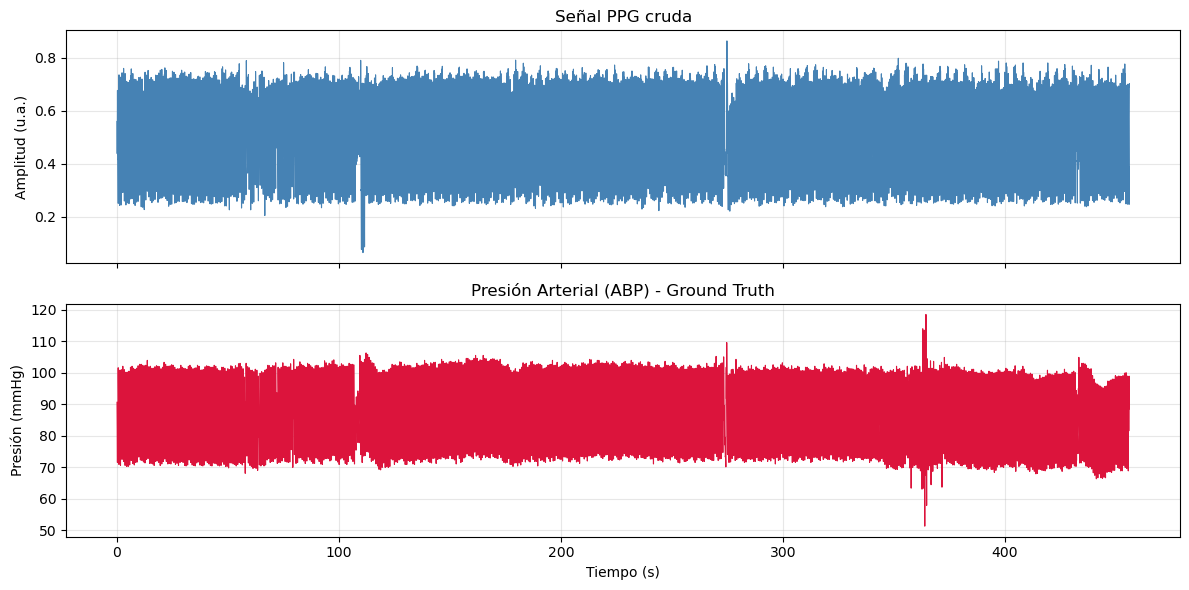

In [4]:
fs = 125  # frecuencia de muestreo en Hz
t = np.arange(len(ppg)) / fs  # convertir muestras a segundos

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, ppg, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Amplitud (u.a.)')
axes[0].set_title('Señal PPG cruda')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, abp, color='crimson', linewidth=0.8)
axes[1].set_ylabel('Presión (mmHg)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_title('Presión Arterial (ABP) - Ground Truth')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Zoom a 10 segundos
Con toda la señal (~488s) no se ve bien la forma de cada pulso.
Nos quedamos con los primeros 10 segundos para ver el detalle.

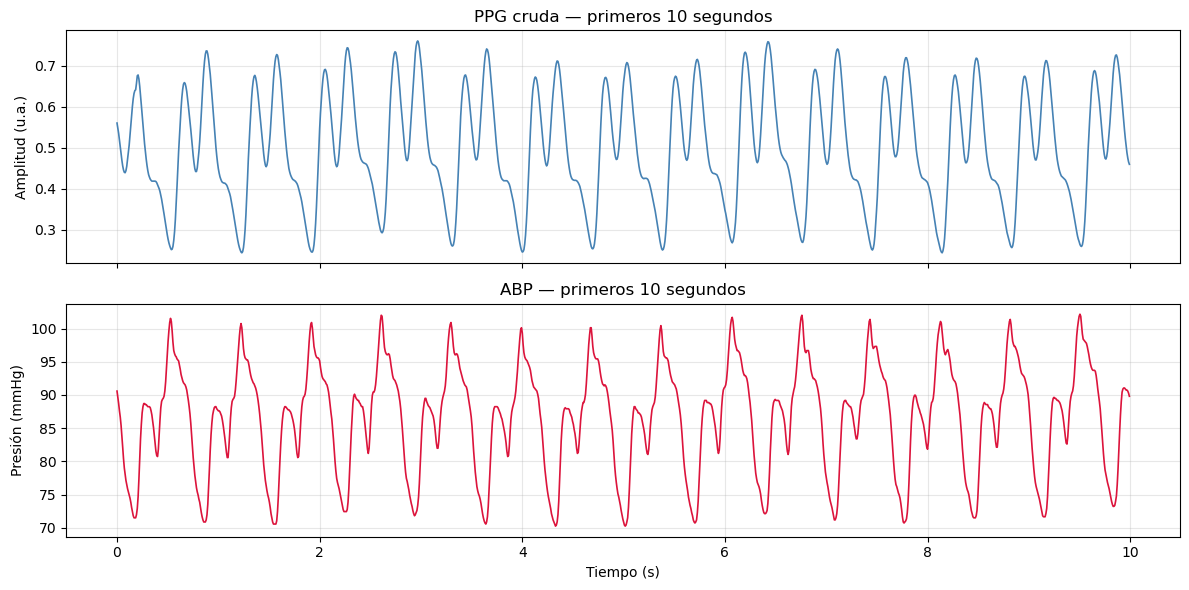

In [5]:
# primeros 10 segundos = 10 * 125 = 1250 muestras
inicio = 0
fin = 10
muestra_ini = inicio * fs
muestra_fin = fin * fs

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t[muestra_ini:muestra_fin], ppg[muestra_ini:muestra_fin],
             color='steelblue', linewidth=1.2)
axes[0].set_ylabel('Amplitud (u.a.)')
axes[0].set_title('PPG cruda — primeros 10 segundos')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[muestra_ini:muestra_fin], abp[muestra_ini:muestra_fin],
             color='crimson', linewidth=1.2)
axes[1].set_ylabel('Presión (mmHg)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_title('ABP — primeros 10 segundos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis de frecuencias (FFT)
Antes de diseñar el filtro necesitamos saber en qué frecuencias
está la información útil y en cuáles está el ruido.
La FFT nos muestra el "espectro" de la señal.

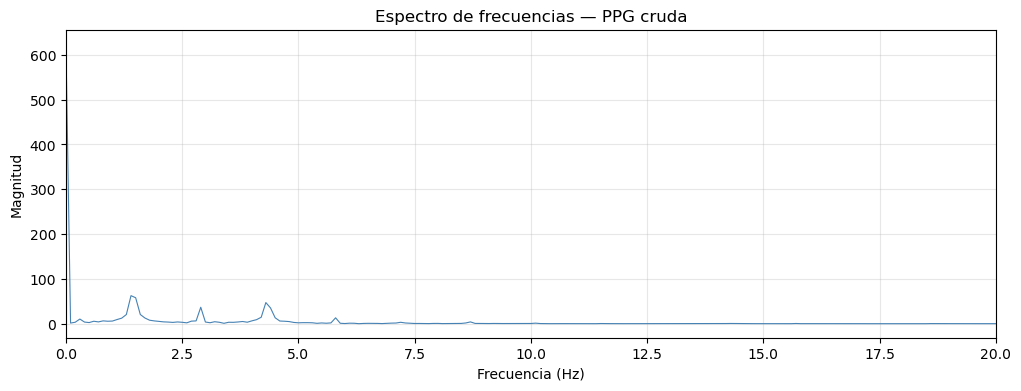

In [6]:
from scipy.fft import fft, fftfreq

segmento = ppg[:10*fs]
N = len(segmento)

# calculamos magnitud y frecuencias correspondientes
# solo tomamos la mitad porque la FFT es simétrica
magnitud = np.abs(fft(segmento))[:N//2]
freqs = fftfreq(N, 1/fs)[:N//2]

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitud, color='steelblue', linewidth=0.8)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.title('Espectro de frecuencias — PPG cruda')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.show()

# el pico principal está en ~2Hz (frecuencia cardíaca ~120bpm)
# los armónicos en 4Hz y 8Hz también son información del pulso
# por encima de 10Hz ya es ruido, casi nada útil

## Filtro Butterworth pasabanda
Con base en el espectro definimos los cortes:
- 0.5 Hz hacia abajo: drift de respiración y movimiento lento
- 8 Hz hacia arriba: ruido eléctrico y de alta frecuencia

El filtro Butterworth es el estándar para señales PPG porque
tiene respuesta plana en la banda de paso (no distorsiona la forma del pulso).

Usamos filtfilt en lugar de lfilter para evitar desfase de fase —
importante cuando queremos detectar el momento exacto de cada pico.

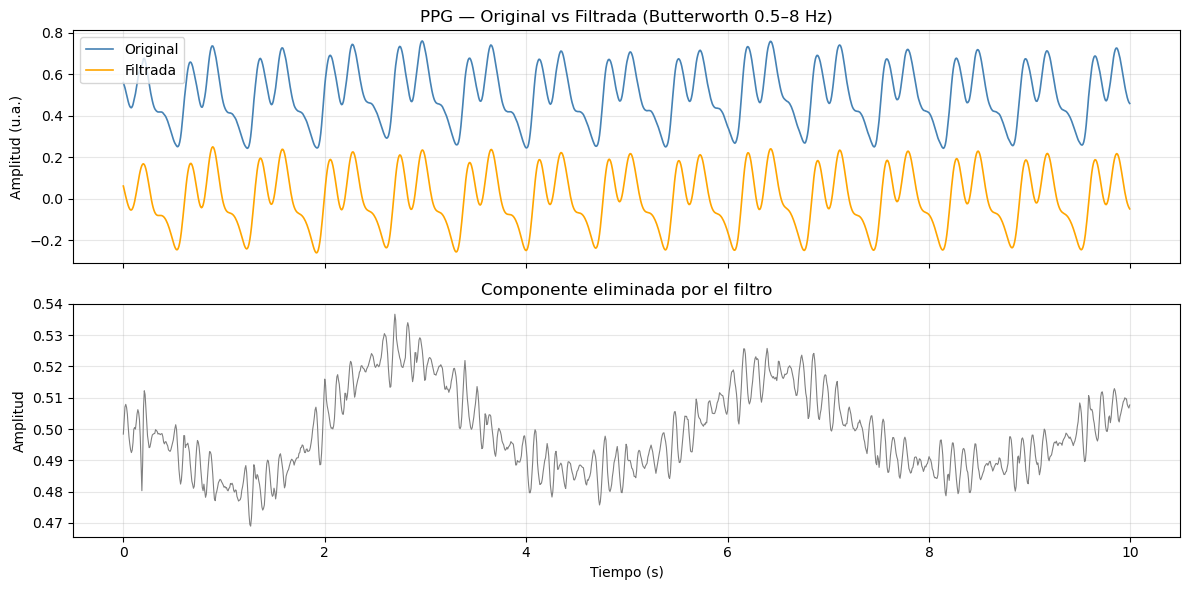

In [7]:
from scipy.signal import butter, filtfilt

def filtro_butterworth(señal, fs, f_low=0.5, f_high=8.0, orden=4):
    nyq = fs / 2  # frecuencia de Nyquist = mitad de la frecuencia de muestreo
    b, a = butter(orden, [f_low/nyq, f_high/nyq], btype='band')
    return filtfilt(b, a, señal)  # filtrado sin desfase

ppg_filtrada = filtro_butterworth(ppg, fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t[:10*fs], ppg[:10*fs], color='steelblue', linewidth=1.2, label='Original')
axes[0].plot(t[:10*fs], ppg_filtrada[:10*fs], color='orange', linewidth=1.2, label='Filtrada')
axes[0].set_ylabel('Amplitud (u.a.)')
axes[0].set_title('PPG — Original vs Filtrada (Butterworth 0.5–8 Hz)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# la diferencia entre ambas es lo que el filtro eliminó
axes[1].plot(t[:10*fs], ppg[:10*fs] - ppg_filtrada[:10*fs],
             color='gray', linewidth=0.8)
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_title('Componente eliminada por el filtro')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Normalización para comparar formas
El filtro pasabanda elimina la componente DC (el valor promedio),
por eso la señal filtrada aparece centrada en cero.
Normalizamos entre 0 y 1 para comparar solo la forma.

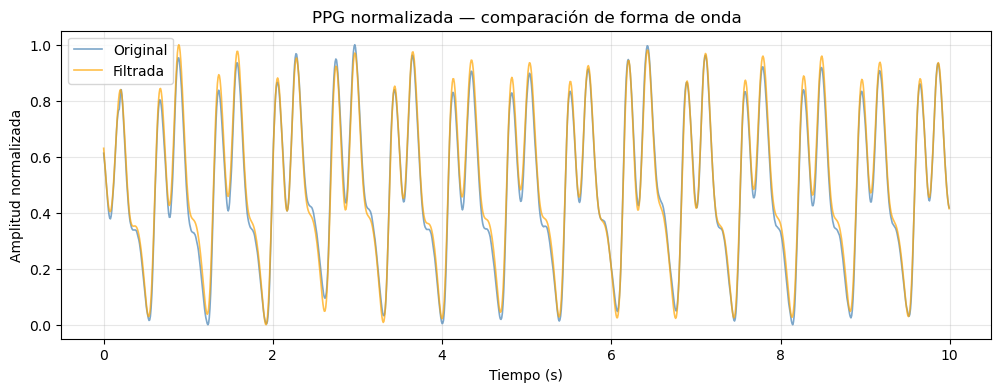

In [8]:
def normalizar(señal):
    return (señal - señal.min()) / (señal.max() - señal.min())

ppg_norm = normalizar(ppg[:10*fs])
ppg_filt_norm = normalizar(ppg_filtrada[:10*fs])

plt.figure(figsize=(12, 4))
plt.plot(t[:10*fs], ppg_norm, color='steelblue', linewidth=1.2, label='Original', alpha=0.7)
plt.plot(t[:10*fs], ppg_filt_norm, color='orange', linewidth=1.2, label='Filtrada', alpha=0.7)
plt.ylabel('Amplitud normalizada')
plt.xlabel('Tiempo (s)')
plt.title('PPG normalizada — comparación de forma de onda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Detección de presión sistólica y diastólica
La presión sistólica es el pico máximo de cada pulso ABP.
La presión diastólica es el valle mínimo entre pulsos.

find_peaks detecta automáticamente estos puntos.
El parámetro distance=fs*0.5 evita detectar dos picos
dentro del mismo latido (mínimo 0.5s entre picos = max 120bpm).

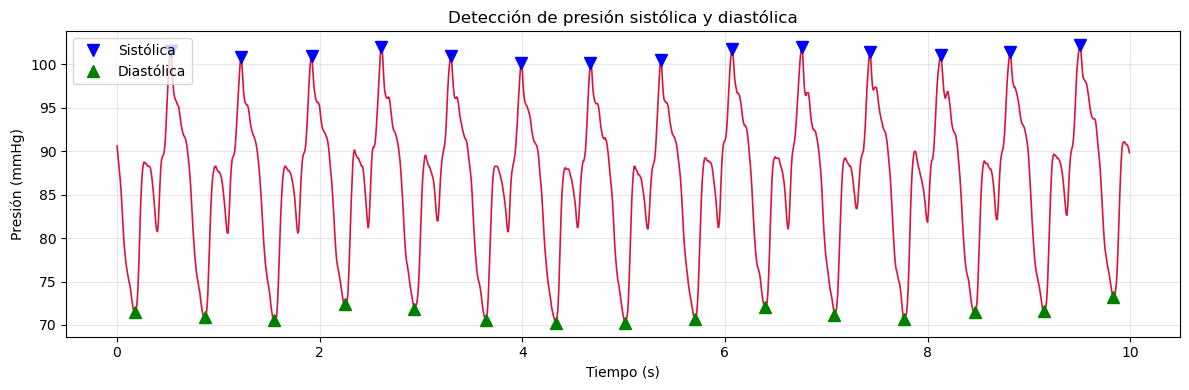

Sistólica promedio:  101.6 mmHg
Diastólica promedio: 71.6 mmHg


In [9]:
from scipy.signal import find_peaks

# picos = sistólica, valles = diastólica (por eso invertimos la señal)
picos, _  = find_peaks(abp, distance=fs*0.5, height=80)
valles, _ = find_peaks(-abp, distance=fs*0.5)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t[:10*fs], abp[:10*fs], color='crimson', linewidth=1.2)

picos_10  = picos[picos < 10*fs]
valles_10 = valles[valles < 10*fs]

ax.plot(t[picos_10],  abp[picos_10],  'v', color='blue',  markersize=8, label='Sistólica')
ax.plot(t[valles_10], abp[valles_10], '^', color='green', markersize=8, label='Diastólica')

ax.set_ylabel('Presión (mmHg)')
ax.set_xlabel('Tiempo (s)')
ax.set_title('Detección de presión sistólica y diastólica')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

sbp = abp[picos].mean()
dbp = abp[valles].mean()
print(f"Sistólica promedio:  {sbp:.1f} mmHg")
print(f"Diastólica promedio: {dbp:.1f} mmHg")

## Simulación de ruido del MAX30100
Para probar que el filtro funciona con señal real del sensor,
le agregamos tres tipos de ruido que produce el hardware:

1. Ruido gaussiano — interferencia electrónica del circuito
2. Ruido de movimiento — cuando el paciente mueve la muñeca (0.3 Hz)
3. Interferencia de red eléctrica — 60 Hz de la corriente alterna

Después aplicamos el mismo filtro Butterworth y medimos cuánto mejoró.

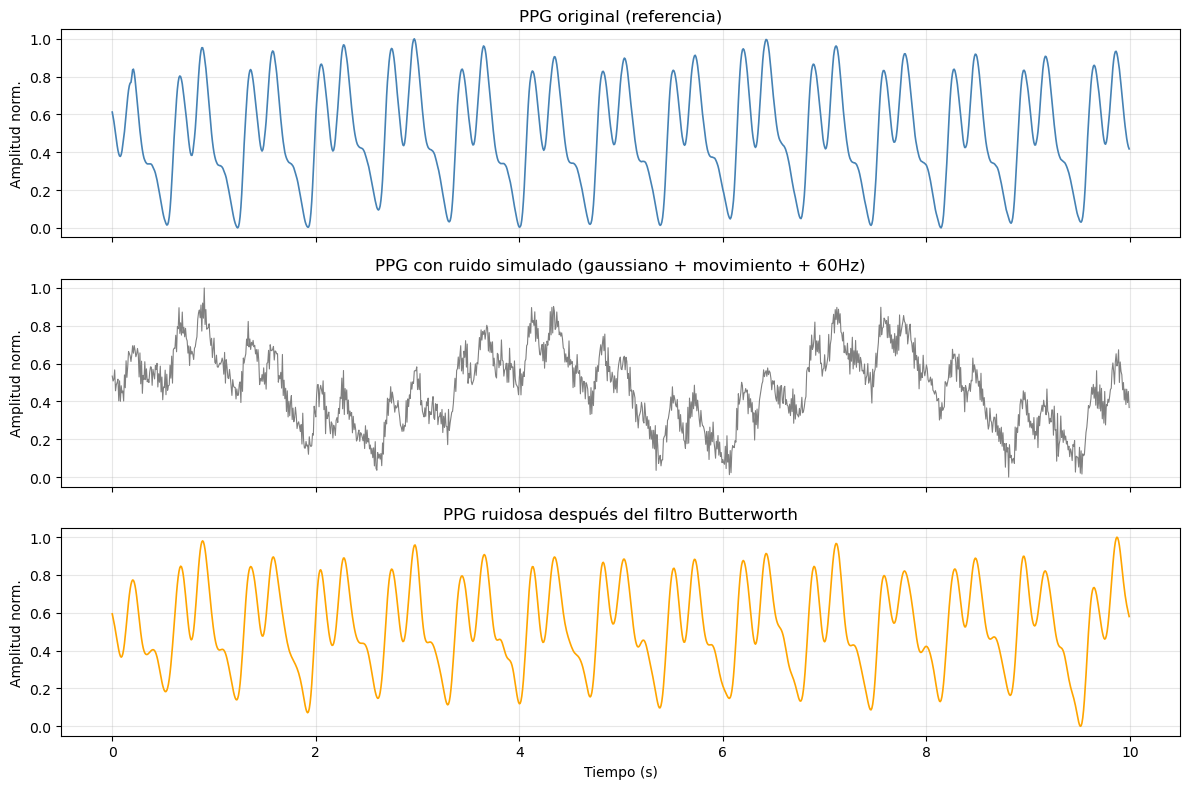

In [10]:
np.random.seed(42)  # para que el ruido sea reproducible
N = len(ppg[:10*fs])

ruido_gaussiano  = np.random.normal(0, 0.05, N)
ruido_movimiento = 0.3 * np.sin(2 * np.pi * 0.3 * t[:N])
ruido_linea      = 0.05 * np.sin(2 * np.pi * 60 * t[:N])

ppg_ruidosa = ppg[:N] + ruido_gaussiano + ruido_movimiento + ruido_linea

ppg_ruidosa_filtrada = filtro_butterworth(ppg_ruidosa, fs)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t[:N], normalizar(ppg[:N]), color='steelblue', linewidth=1.2)
axes[0].set_title('PPG original (referencia)')
axes[0].set_ylabel('Amplitud norm.')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:N], normalizar(ppg_ruidosa), color='gray', linewidth=0.8)
axes[1].set_title('PPG con ruido simulado (gaussiano + movimiento + 60Hz)')
axes[1].set_ylabel('Amplitud norm.')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t[:N], normalizar(ppg_ruidosa_filtrada), color='orange', linewidth=1.2)
axes[2].set_title('PPG ruidosa después del filtro Butterworth')
axes[2].set_ylabel('Amplitud norm.')
axes[2].set_xlabel('Tiempo (s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Métrica SNR (Signal-to-Noise Ratio)
El SNR mide qué tan "limpia" está la señal respecto al ruido.
Se mide en decibeles (dB) — a mayor valor, mejor.

Un aumento de 6 dB equivale a reducir el ruido a la mitad.

In [11]:
def calcular_snr(señal_limpia, señal_ruidosa):
    ruido = señal_ruidosa - señal_limpia
    potencia_señal = np.mean(señal_limpia**2)
    potencia_ruido = np.mean(ruido**2)
    return 10 * np.log10(potencia_señal / potencia_ruido)

ref      = normalizar(ppg[:N])
ruidosa  = normalizar(ppg_ruidosa)
filtrada = normalizar(ppg_ruidosa_filtrada)

snr_antes   = calcular_snr(ref, ruidosa)
snr_despues = calcular_snr(ref, filtrada)

print(f"SNR antes del filtro:   {snr_antes:.2f} dB")
print(f"SNR después del filtro: {snr_despues:.2f} dB")
print(f"Mejora:                 {snr_despues - snr_antes:.2f} dB")

SNR antes del filtro:   7.35 dB
SNR después del filtro: 18.04 dB
Mejora:                 10.69 dB
